# 1. Setup & Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

from collections import Counter
import re

## Data Load

In [2]:
df = pd.read_csv("/workspaces/AM2_erp_programme_automataion/data/preprocessed/newsletters_preprocessed.csv")

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1654 non-null   object 
 1   newsletter_number   1654 non-null   int64  
 2   issue_date          1654 non-null   object 
 3   theme               1654 non-null   object 
 4   subtheme            95 non-null     object 
 5   title               1654 non-null   object 
 6   description         1354 non-null   object 
 7   link                1654 non-null   object 
 8   new_theme           1654 non-null   object 
 9   domain              1643 non-null   object 
 10  organisation        1399 non-null   object 
 11  org_broad_category  1399 non-null   object 
 12  org_category        1399 non-null   object 
 13  item_type           1654 non-null   object 
 14  title_length        1654 non-null   int64  
 15  description_length  1354 non-null   float64
 16  text  

,id,newsletter_number,issue_date,theme,subtheme,title,description,link,new_theme,domain,organisation,org_broad_category,org_category,item_type,title_length,description_length,text,text_length_words
0,a65013c4-ce18-43d8-82a5-b7707d8ecce9,1,11 July 2023,DfE,NaN,"Reject fewer teacher applicants, DfE tells tra...","Susan Acland-Hood, the DfE's permanent secreta...",https://schoolsweek.co.uk/reject-fewer-teacher...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,51,163.0,"Reject fewer teacher applicants, DfE tells tra...",35
1,550a3ffb-c512-4117-b6fa-eff93855fd89,1,11 July 2023,DfE,NaN,Revealed: the experts advising ministers on te...,The Department for Education has appointed an ...,https://schoolsweek.co.uk/revealed-the-experts...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,75,408.0,Revealed: the experts advising ministers on te...,74
2,c79baa9f-775b-444e-bbd4-dc111e4846f4,1,11 July 2023,Calls for evidence,NaN,Deadline 23 August 2023,Education secretary Gillian Keegan has launche...,https://schoolsweek.co.uk/chatgpt-keegan-launc...,policy_practice_research,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,23,174.0,Deadline 23 August 2023 Education secretary Gi...,32
3,9ec40ab1-2d2e-460b-8c82-1ed4a121d770,1,11 July 2023,DfE,NaN,Ofqual and DfE studying 'feasibility' of 'full...,Some exam boards are already piloting on-scree...,https://schoolsweek.co.uk/teachers-back-digita...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,62,254.0,Ofqual and DfE studying 'feasibility' of 'full...,36
4,4776c84a-705e-4c49-aa46-8c759d90540c,1,11 July 2023,What are the politicians saying?,NaN,Labour,Revealed: The full details of Labour's educati...,https://schoolsweek.co.uk/revealed-the-full-de...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,6,232.0,Labour Revealed: The full details of Labour's ...,37


In [4]:
#drop unnecessary columns
cols_to_keep = [  'id', 'newsletter_number', 'issue_date', 'new_theme',
    'organisation', 'org_broad_category', 'item_type', 'text', 'text_length_words']

df = df[cols_to_keep].copy().rename(columns={'new_theme': 'nl_section'})

In [5]:
cat_cols = ['nl_section', 'organisation', 'org_broad_category', 'item_type']
df[cat_cols] = df[cat_cols].astype('category')

In [6]:
# issue_date to datetime
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst = True, errors='coerce')
print(df['issue_date'].isna().sum())
print(df['issue_date'].min(), df['issue_date'].max())

0
2023-07-11 00:00:00 2026-03-06 00:00:00


In [7]:
# Rename the confusing 'article' type
df['item_type'] = df['item_type'].replace({'article': 'announcement'})


/tmp/ipykernel_87894/1909427496.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['item_type'] = df['item_type'].replace({'article': 'announcement'})


## Shared Lookups

In [8]:
# Section rename mapping
section_rename = {
    'teacher_rrd': 'Teacher recruitment, retention & development',
    'edtech': 'EdTech',
    'political_environment_key_organisations': 'Political environment & key orgs',
    'four_nations': 'Four Nations',
    'policy_practice_research': 'Research \u2013 Practice \u2013 Policy',
    'what_matters_ed': 'What matters in education?',
    'update_from_pi': 'Updates from PI',
    'update_from_programme': 'Updates from the Programme'
}

# Organisation rename mapping
org_rename = {
    'schools_week': 'Schools Week',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'bera': 'BERA',
    'epi': 'EPI',
    'tes': 'TES',
    'ucl': 'UCL',
    'teacher_tapp': 'Teacher Tapp',
    'uk_parliament': 'UK Parliament',
    'bera_journals': 'BERA Journals',
    'oecd': 'OECD',
    'chartered_college_of_teaching': 'Chartered College',
    'conversation': 'The Conversation',
    'eef': 'EEF',
    'politics_home': 'Politics Home',
    '5rights_foundation': '5Rights Foundation',
    'guardian': 'The Guardian',
    'ofcom': 'Ofcom',
    'childrens_commissioner': "Children's Commissioner",
    'digital_poverty_alliance': 'Digital Poverty Alliance',
    'ada_lovelace_institute': 'Ada Lovelace Institute',
    'nuffield_foundation': 'Nuffield Foundation',
    'lse': 'LSE',
    'ofsted': 'Ofsted'
}

# Full date range for time series
full_range = pd.date_range(start='2023-07-01', end='2026-02-01', freq='MS')

# Year column
df['year'] = df['issue_date'].dt.year

# Stopwords for keyword analysis
stopwords = {'the', 'and', 'for', 'that', 'this', 'with', 'are', 'has', 'have', 
             'been', 'its', 'from', 'will', 'their', 'they', 'which', 'more',
             'also', 'but', 'not', 'new', 'was', 'who', 'how', 'what'}

# Teacher RRD frames
frames = {
    'supply_pipeline': ['recruitment', 'retention', 'training', 'workforce', 'supply', 
                        'shortage', 'shortages', 'itt', 'recruit', 'trainees', 'trainee', 
                        'graduates', 'providers', 'targets', 'bursaries', 'incentives', 
                        'visa', 'overseas', 'accreditation'],
    'working_conditions': ['pay', 'workload', 'flexible', 'wellbeing', 'stress', 'burnout', 
                       'mental', 'health', 'pressures', 'costs', 'housing', 'salary', 
                       'wages', 'pension', 'conditions'],
    'professional_development': ['cpd', 'professional development', 'mentoring', 'early career', 
                                'npqs', 'npq', 'ect', 'induction', 'standards', 'qualified', 
                                'progression', 'career development'],
    'diversity_equity': ['diversity', 'ethnic', 'gender', 'bame', 'inclusion', 'equitable',
                        'representation', 'disadvantaged', 'minority', 'underrepresented'],
    'political_framing': ['crisis', 'reform', 'government', 'minister', 'policy', 'ofsted', 
                         'dfe', 'labour', 'conservative', 'legislation', 'accountability',
                         'inspection', 'political']
}

## Subsets

In [26]:
# === Subsets ===
rrd = df[df['nl_section'] == 'teacher_rrd']
edtech = df[df['nl_section'] == 'edtech']

# === Time series ===
rrd_per_month = rrd.groupby(rrd['issue_date'].dt.to_period('M')).size()
rrd_per_month.index = rrd_per_month.index.to_timestamp()
rrd_per_month = rrd_per_month.reindex(full_range, fill_value=0)

# === Top 15 org lists ===
top15 = ['schools_week', 'nfer', 'uk_government', 'bera', 'epi', 'tes', 'ucl',
         'teacher_tapp', 'uk_parliament', 'bera_journals', 'oecd', 
         'chartered_college_of_teaching', 'conversation', 'eef', 'politics_home']
rrd_top15 = rrd[rrd['organisation'].isin(top15)]

edtech_top15_list = edtech['organisation'].value_counts().head(15).index.tolist()
edtech_top15 = edtech[edtech['organisation'].isin(edtech_top15_list)]

# === People ===
people = ['phillipson', 'gibb']

# 2. Corpus Overview

## Sections, Organisations & Item Types

In [9]:
df['org_broad_category'].value_counts()

org_broad_category
media_sector                             386
government_public_sector                 327
academic_sector                          242
knowledge_mobiliser_think_tank_sector    162
civil_society_nonprofit_sector           113
research_evidence_sector                 100
other_miscellaneous                       40
digital_social_media_platforms            15
commercial_private_sector                 14
Name: count, dtype: int64

In [10]:
df['nl_section'].value_counts()

nl_section
political_environment_key_organisations    315
what_matters_ed                            256
teacher_rrd                                233
edtech                                     226
policy_practice_research                   221
four_nations                               165
update_from_pi                             143
update_from_programme                       95
Name: count, dtype: int64

In [11]:
df['item_type'].value_counts()

item_type
report                 476
news_article           337
announcement           297
government_document    271
academic_article       163
blog_post               95
linkedin_post            7
video                    6
tweet                    2
Name: count, dtype: int64

## Quality Check (items per issue)

In [12]:
#issue_size
issue_sizes = df.groupby('newsletter_number').size()
print(issue_sizes.describe())

count    102.000000
mean      16.215686
std        4.440202
min        7.000000
25%       13.000000
50%       16.000000
75%       19.000000
max       30.000000
dtype: float64


In [13]:
issue_sizes[issue_sizes == 7]

newsletter_number
10    7
dtype: int64

## Section Distribution

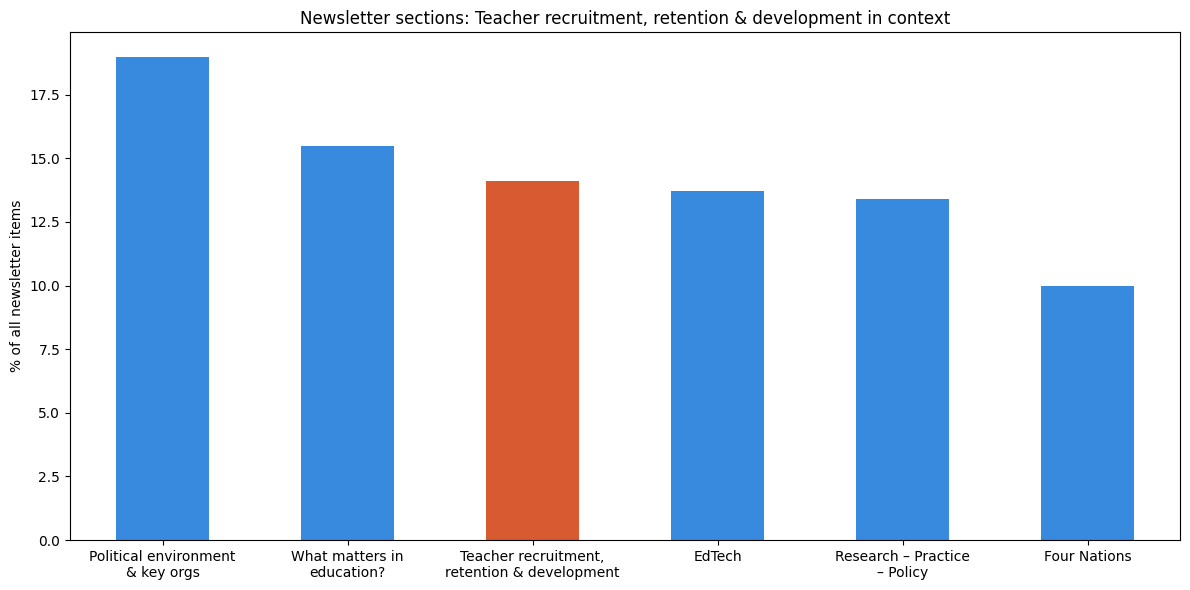

In [16]:
import textwrap

# Rename sections from snake_case to readable names
section_rename = {
    'teacher_rrd': 'Teacher recruitment,\nretention & development',
    'edtech': 'EdTech',
    'political_environment_key_organisations': 'Political environment\n& key orgs',
    'four_nations': 'Four Nations',
    'policy_practice_research': 'Research – Practice\n– Policy',
    'what_matters_ed': 'What matters in\neducation?',
    'update_from_pi': 'Updates from PI',
    'update_from_programme': 'Updates from the\nProgramme'
}

# Compare teacher_rrd to other nl_sections - SIMPLE VERSION
section_counts = df['nl_section'].value_counts(dropna=True)
section_counts.index = section_counts.index.map(section_rename)
section_pct = (section_counts / len(df) * 100).round(1)

# Keep top 6 sections only
top_sections = section_counts.head(6)
top_pct = (top_sections / len(df) * 100).round(1)

# Create simple bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#D85A30' if 'Teacher recruitment' in str(x) else '#378ADD' for x in top_pct.index]
top_pct.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('% of all newsletter items')
ax.set_xlabel('')
ax.set_title('Newsletter sections: Teacher recruitment, retention & development in context')  # FIXED TITLE
plt.xticks(rotation=0, ha='center')  # HORIZONTAL LABELS
plt.tight_layout()
plt.savefig('bera_outputs/09_nl_sections_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Sections Over Time (by year)

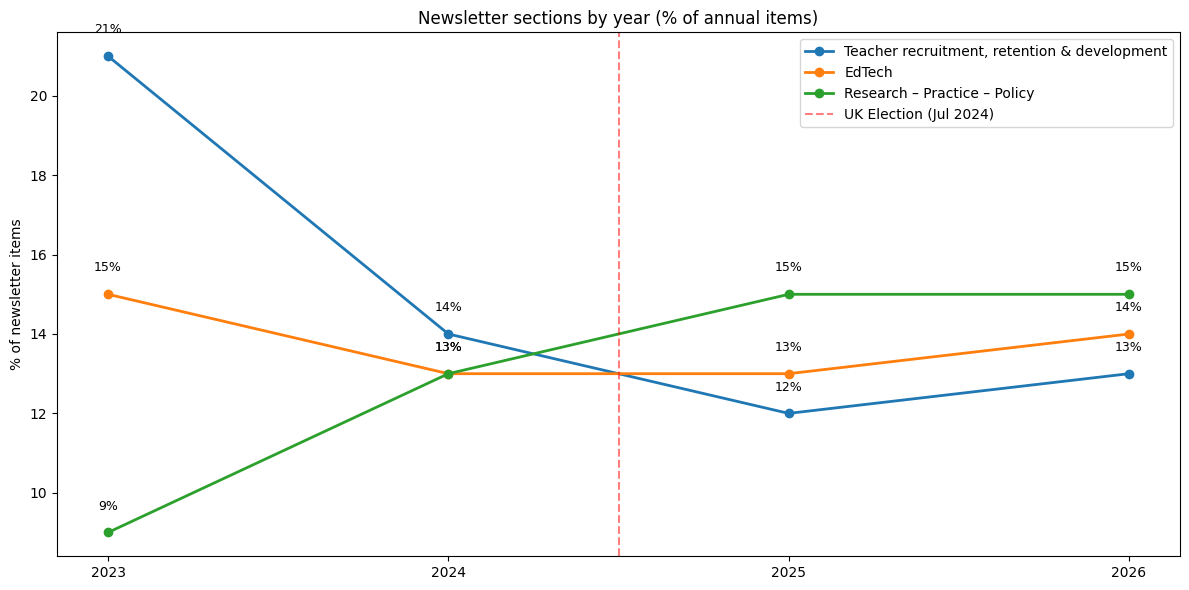

In [17]:
# Section names for legend
section_labels = {
    'teacher_rrd': 'Teacher recruitment, retention & development',
    'edtech': 'EdTech',
    'policy_practice_research': 'Research – Practice – Policy'
}

# Group by year and section
df['year'] = df['issue_date'].dt.year
years = sorted(df['year'].dropna().unique())
totals = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 6))

for section, label in section_labels.items():
    counts = df[df['nl_section'] == section].groupby('year').size()
    pct = (counts / totals * 100).reindex(years, fill_value=0).round(0).astype(int)
    ax.plot(years, pct.values, marker='o', linewidth=2, label=label)
    for j, val in enumerate(pct.values):
        ax.text(years[j], val + 0.5, f'{val}%', ha='center', va='bottom', fontsize=9)

ax.axvline(2024.5, color='red', linestyle='--', alpha=0.5, label='UK Election (Jul 2024)')
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years])
ax.set_ylabel('% of newsletter items')
ax.set_xlabel('')
ax.set_title('Newsletter sections by year (% of annual items)')
ax.legend()
plt.tight_layout()
plt.savefig('bera_outputs/04_items_per_year_by_section.png', dpi=150, bbox_inches='tight')
plt.show()


# 3. Teacher Recruitment, Retention & Development

In [18]:
rrd = df[df['nl_section'] == 'teacher_rrd']
print(f"teacher_rrd: {len(rrd)} items ({len(rrd)/len(df)*100:.1f}% of corpus)")
print(f"Unique organisations: {rrd['organisation'].nunique()}")

teacher_rrd: 233 items (14.1% of corpus)
Unique organisations: 42


## Top Organisations in Teacher RRD

In [19]:
corpus_org = df['organisation'].value_counts()
rrd_org = rrd['organisation'].value_counts()

ratio_org = pd.DataFrame({
    'corpus_n': corpus_org,
    'rrd_n': rrd_org
}).fillna(0)

ratio_org['rrd_ratio'] = ratio_org['rrd_n'] / ratio_org['corpus_n']
ratio_org['corpus_pct'] = ratio_org['corpus_n'] / len(df) * 100
ratio_org['rrd_pct'] = ratio_org['rrd_n'] / len(rrd) * 100
ratio_org.to_csv('bera_outputs/table_org_comparison.csv')

In [20]:
top15_org = ratio_org[ratio_org['rrd_n'] > 0].sort_values('rrd_n', ascending=False).head(15)
top15_org.to_csv('bera_outputs/table_top15_orgs.csv')
top15_org

,corpus_n,rrd_n,rrd_ratio,corpus_pct,rrd_pct
organisation,,,,,
schools_week,180,64,0.355556,10.882709,27.467811
nfer,31,18,0.580645,1.874244,7.725322
uk_government,116,18,0.155172,7.013301,7.725322
bera,43,9,0.209302,2.599758,3.862661
epi,37,8,0.216216,2.237001,3.433476
tes,25,8,0.320000,1.511487,3.433476
ucl,86,7,0.081395,5.199516,3.004292
teacher_tapp,12,6,0.500000,0.725514,2.575107
uk_parliament,58,6,0.103448,3.506651,2.575107


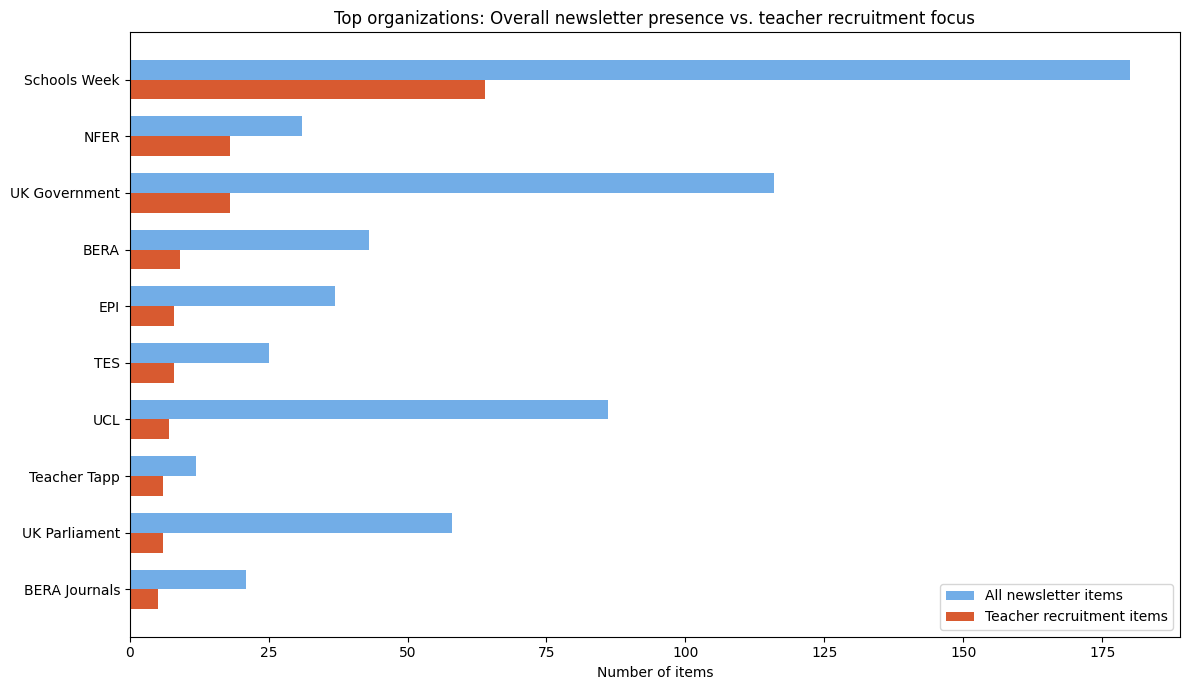


Key patterns:
Schools Week: 180 total → 64 teacher_rrd (36%)
NFER: 31 total → 18 teacher_rrd (58%)


In [21]:
# Top 10 organizations - overall vs teacher_rrd
top10 = top15_org.head(10).copy()

# Rename organizations
org_rename = {
    'schools_week': 'Schools Week',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'bera': 'BERA',
    'epi': 'EPI',
    'tes': 'TES',
    'ucl': 'UCL',
    'teacher_tapp': 'Teacher Tapp',
    'uk_parliament': 'UK Parliament',
    'bera_journals': 'BERA Journals',
    'oecd': 'OECD',
    'chartered_college_of_teaching': 'Chartered College',
    'conversation': 'The Conversation',
    'eef': 'EEF',
    'politics_home': 'Politics Home'
}

top10.index = top10.index.map(org_rename)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top10))
width = 0.35

ax.barh(x - width/2, top10['corpus_n'], width, label='All newsletter items', color='#378ADD', alpha=0.7)
ax.barh(x + width/2, top10['rrd_n'], width, label='Teacher recruitment items', color='#D85A30')

ax.set_yticks(x)
ax.set_yticklabels(top10.index)
ax.set_xlabel('Number of items')
ax.set_title('Top organizations: Overall newsletter presence vs. teacher recruitment focus')
ax.legend()
ax.invert_yaxis()  # Top org at top

plt.tight_layout()
plt.savefig('bera_outputs/10_top_orgs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insights
print("\nKey patterns:")
print(f"Schools Week: {top10.loc['Schools Week', 'corpus_n']:.0f} total → {top10.loc['Schools Week', 'rrd_n']:.0f} teacher_rrd ({top10.loc['Schools Week', 'rrd_ratio']:.0%})")
print(f"NFER: {top10.loc['NFER', 'corpus_n']:.0f} total → {top10.loc['NFER', 'rrd_n']:.0f} teacher_rrd ({top10.loc['NFER', 'rrd_ratio']:.0%})")

## Sector Proportions

In [23]:
corpus_sector = df['org_broad_category'].value_counts()
rrd_sector = rrd['org_broad_category'].value_counts()
ratio_df = pd.DataFrame({'corpus_n': corpus_sector, 'rrd_n': rrd_sector}).fillna(0)
ratio_df['rrd_ratio'] = ratio_df['rrd_n'] / ratio_df['corpus_n']

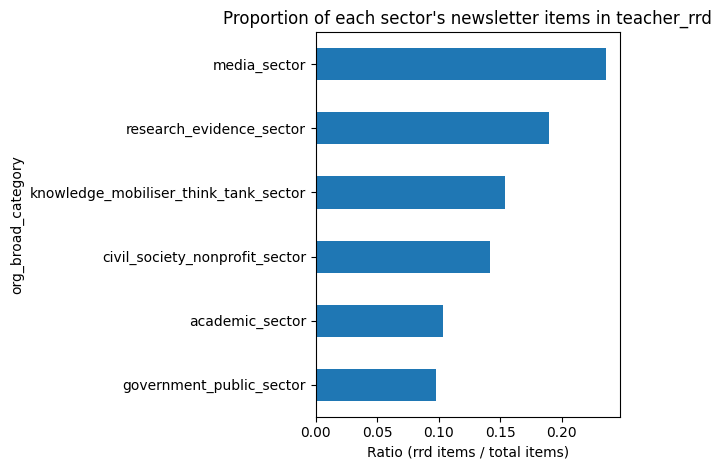

In [24]:
ratio_df[ratio_df['rrd_n'] > 0]['rrd_ratio'].sort_values().plot(
    kind='barh', 
    title='Proportion of each sector\'s newsletter items in teacher_rrd'
)
plt.xlabel('Ratio (rrd items / total items)')
plt.tight_layout()
plt.savefig('bera_outputs/01_sector_proportion_barh.png', dpi=150, bbox_inches='tight')
plt.show()

#### interpretation - Schools Week dominates in volume (64 items, 27% of all teacher_rrd), while NFER and UK Government tie on items (18 each) but NFER punches above its weight with a much higher ratio -- meaning the editorial team drew on NFER far more selectively for recruitment content than it did government sources.
corpus_n -- number of items from that organisation in the whole newsletter corpus (1363 items)
rrd_n -- number of items from that organisation in teacher_rrd (233 items)
rrd_ratio -- rrd_n divided by corpus_n -- what proportion of that organisation's total newsletter items are in teacher_rrd
corpus_pct -- that organisation's share of the whole corpus. Schools Week at 10.9% means they contributed 1 in 10 of all newsletter items
rrd_pct -- that organisation's share of all teacher_rrd items. Schools Week at 27.5% means they contributed more than 1 in 4 of all recruitment items

## Teacher RRD Over Time

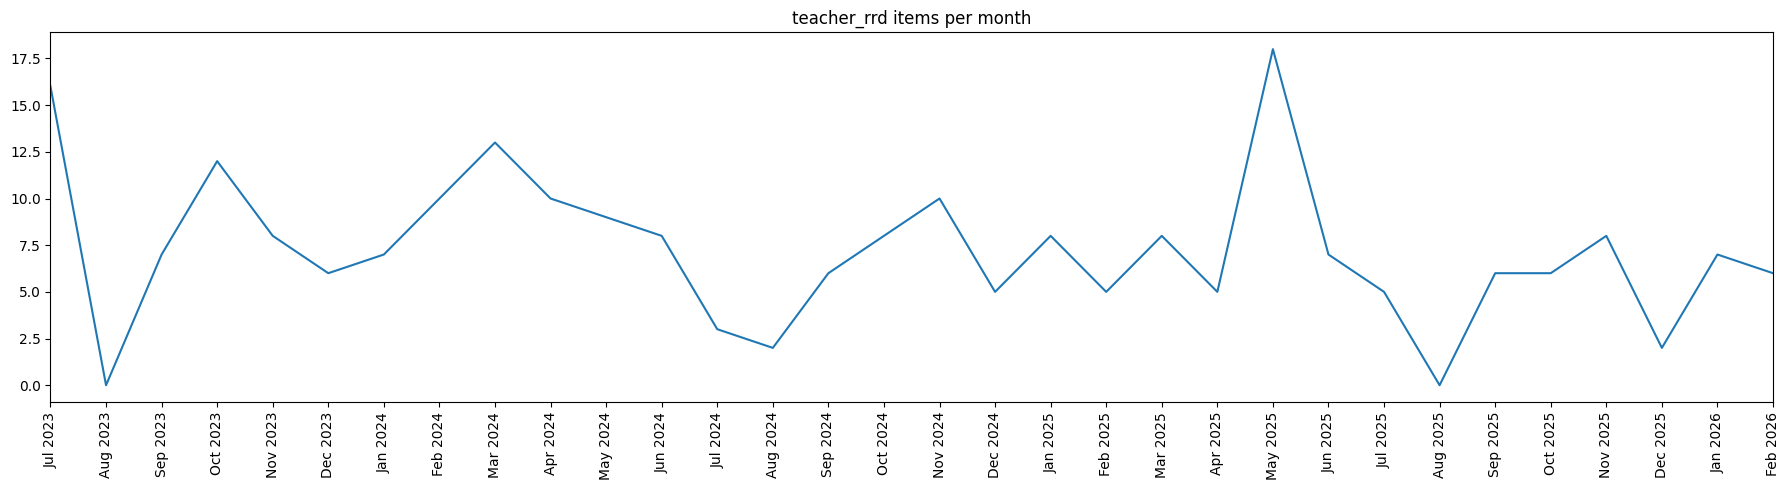

In [27]:
fig, ax = plt.subplots(figsize=(18, 5))
rrd_per_month.plot(kind='line', ax=ax, title='teacher_rrd items per month')
ax.set_xticks(rrd_per_month.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in rrd_per_month.index], rotation=90)
plt.tight_layout()
plt.savefig('bera_outputs/02_rrd_items_per_month.png', dpi=150, bbox_inches='tight')
plt.show()

## Item Type Distribution

In [28]:
corpus_item = df['item_type'].value_counts()
rrd_item = rrd['item_type'].value_counts()

item_df = pd.DataFrame({
    'corpus_n': corpus_item,
    'rrd_n': rrd_item
}).fillna(0)

item_df['corpus_pct'] = (item_df['corpus_n'] / len(df) * 100).round(1)
item_df['rrd_pct'] = (item_df['rrd_n'] / len(rrd) * 100).round(1)
item_df['rrd_ratio'] = (item_df['rrd_n'] / item_df['corpus_n']).round(2)
item_df_sorted = item_df.sort_values('rrd_ratio', ascending=False)
item_df_sorted.to_csv('bera_outputs/table_item_type_comparison.csv')
item_df_sorted

,corpus_n,rrd_n,corpus_pct,rrd_pct,rrd_ratio
item_type,,,,,
news_article,337,87,20.4,37.3,0.26
report,476,74,28.8,31.8,0.16
academic_article,163,16,9.9,6.9,0.10
government_document,271,24,16.4,10.3,0.09
announcement,297,24,18.0,10.3,0.08
blog_post,95,8,5.7,3.4,0.08
linkedin_post,7,0,0.4,0.0,0.00
tweet,2,0,0.1,0.0,0.00
video,6,0,0.4,0.0,0.00


### Teacher_rrd is disproportionately driven by news articles (37% of recruitment items vs 20% of the full corpus), suggesting recruitment discourse is more reactive and event-driven than the newsletter's output overall.

## Keywords in Teacher RRD

In [29]:
text = ' '.join(rrd['text'].dropna().tolist()).lower()
words = re.findall(r'\b[a-z]{3,}\b', text)

stopwords = {'the', 'and', 'for', 'that', 'this', 'with', 'are', 'has', 'have', 
             'been', 'its', 'from', 'will', 'their', 'they', 'which', 'more',
             'also', 'but', 'not', 'new', 'was', 'who', 'how', 'what'}

counts = Counter(w for w in words if w not in stopwords)
counts.most_common(10)

[('teacher', 178),
 ('teachers', 157),
 ('schools', 100),
 ('education', 77),
 ('retention', 75),
 ('school', 75),
 ('recruitment', 74),
 ('report', 61),
 ('teaching', 56),
 ('england', 39)]

## Frame Analysis

| Frame | Definition | Keywords | % of teacher_rrd items |
|-------|-----------|----------|----------------------|
| **Supply/pipeline** | Items about the recruitment, training and retention pipeline — getting enough teachers into and through the system | recruitment, retention, training, workforce, supply, shortage(s), ITT, recruit, trainees, graduates, providers, targets, bursaries, incentives, visa, overseas, accreditation | **53%** (most dominant) |
| **Political framing / Crisis & Reform** | Items that frame teaching through political action, crisis language or reform agendas | crisis, reform, targets, commission, taskforce, inquiry, election, labour, DfE, committee, parliament | **38%** |
| **Professional development** | Items about teachers' ongoing learning, career progression and leadership development | CPD, development, professional, career, NPQs, NPQ, ECF, leadership, leaders, headteacher(s), chartered | **35%** |
| **Working conditions** | Items about pay, workload, wellbeing and the day-to-day experience of teaching | pay, workload, flexible, wellbeing, stress, burnout, mental health, pressures, costs, spending, cuts, maternity, strikes, minimum | **30%** |
| **Diversity & equity** | Items about inclusion, demographic representation and support for disadvantaged groups | ethnic, diversity, disadvantaged, inclusive, communities, demographic, SEND, pupils, children | **12%** (least prominent) |

In [30]:
frame_counts = []
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    count = rrd['text'].str.contains(pattern, case=False, na=False).sum()
    frame_counts.append({'frame': frame, 'n_items': count, 'pct': round(count/len(rrd)*100, 1)})
    print(f"{frame}: {count} items ({count/len(rrd)*100:.1f}%)")

pd.DataFrame(frame_counts).to_csv('bera_outputs/table_frame_counts.csv', index=False)

supply_pipeline: 123 items (52.8%)
working_conditions: 64 items (27.5%)
professional_development: 84 items (36.1%)
diversity_equity: 14 items (6.0%)
political_framing: 111 items (47.6%)


### Frames by Sector

In [31]:
frame_sector = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    frame_sector[frame] = rrd[mask]['org_broad_category'].value_counts()

frame_sector_df = pd.DataFrame(frame_sector).fillna(0).astype(int)
frame_sector_df.to_csv('bera_outputs/table_frame_by_sector.csv')
frame_sector_df

,supply_pipeline,working_conditions,professional_development,diversity_equity,political_framing
org_broad_category,,,,,
academic_sector,11,5,7,1,7
civil_society_nonprofit_sector,5,6,7,1,5
commercial_private_sector,0,0,0,0,0
digital_social_media_platforms,0,0,0,0,0
government_public_sector,17,7,10,0,24
knowledge_mobiliser_think_tank_sector,11,5,14,1,12
media_sector,50,30,26,3,51
other_miscellaneous,0,0,0,0,0
research_evidence_sector,13,3,9,4,9


In [32]:
# Add totals row and column (this modifies frame_sector_df directly)
frame_sector_df.loc['TOTAL'] = frame_sector_df.sum()
frame_sector_df['TOTAL'] = frame_sector_df.sum(axis=1)
frame_sector_df.to_excel('bera_outputs/table_frame_by_sector.xlsx')

# Display it
frame_sector_df  # <-- Changed this line

,supply_pipeline,working_conditions,professional_development,diversity_equity,political_framing,TOTAL
org_broad_category,,,,,,
academic_sector,11,5,7,1,7,31
civil_society_nonprofit_sector,5,6,7,1,5,24
commercial_private_sector,0,0,0,0,0,0
digital_social_media_platforms,0,0,0,0,0,0
government_public_sector,17,7,10,0,24,58
knowledge_mobiliser_think_tank_sector,11,5,14,1,12,43
media_sector,50,30,26,3,51,160
other_miscellaneous,0,0,0,0,0,0
research_evidence_sector,13,3,9,4,9,38


### Frames by Item Type

In [33]:
frame_itemtype_data = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    print(f"\n--- {frame} ---")
    vc = rrd[mask]['item_type'].value_counts()
    print(vc)
    frame_itemtype_data[frame] = vc

pd.DataFrame(frame_itemtype_data).fillna(0).astype(int).to_csv('bera_outputs/table_item_type_by_frame.csv')


--- supply_pipeline ---
item_type
news_article           49
report                 33
announcement           16
government_document    15
academic_article        7
blog_post               3
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- working_conditions ---
item_type
news_article           29
report                 17
announcement            8
government_document     5
blog_post               3
academic_article        2
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- professional_development ---
item_type
report                 32
news_article           25
announcement           10
government_document     7
academic_article        6
blog_post               4
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- diversity_equity ---
item_type
report                 7
announcement           4
news_article     

Supply_pipeline and political_framing are news-dominated - both have news_article as their top item type by a large margin. 
Professional_development is report-dominated - reports come first, ahead of news articles. This frame has a slower, more deliberative epistemic texture -- it's being advanced through research outputs rather than news coverage.
Working_conditions sits in between - news-heavy but with a meaningful report presence. Both reactive (news) and evidence-based (reports) framings of the problem exist here.
Diversity_equity - only 29 items total and no academic articles at all. The frame with the most obvious connection to attainment gaps and disadvantaged pupils is the least evidenced academically in this corpus.
Government_document appears most strongly in supply_pipeline (15) and political_framing (16) - government advance pipeline and political frames, over conditions or professional development frames.

### Frames: Phillipson and Gibb

In [34]:
person_frame_data = []
for person in people:
    print(f"\n--- {person} ---")
    person_items = rrd[rrd['text'].str.contains(person, case=False, na=False)]
    print(f"{len(person_items)} items mention {person}")
    row = {'person': person, 'n_items': len(person_items)}
    for frame, keywords in frames.items():
        pattern = '|'.join(keywords)
        count = person_items['text'].str.contains(pattern, case=False, na=False).sum()
        row[frame] = count
        print(f"  {frame}: {count}")
    person_frame_data.append(row)

pd.DataFrame(person_frame_data).to_csv('bera_outputs/table_person_frame_analysis.csv', index=False)


--- phillipson ---
4 items mention phillipson
  supply_pipeline: 1
  working_conditions: 2
  professional_development: 1
  diversity_equity: 0
  political_framing: 1

--- gibb ---
2 items mention gibb
  supply_pipeline: 2
  working_conditions: 2
  professional_development: 0
  diversity_equity: 0
  political_framing: 2


### Frames Over Time

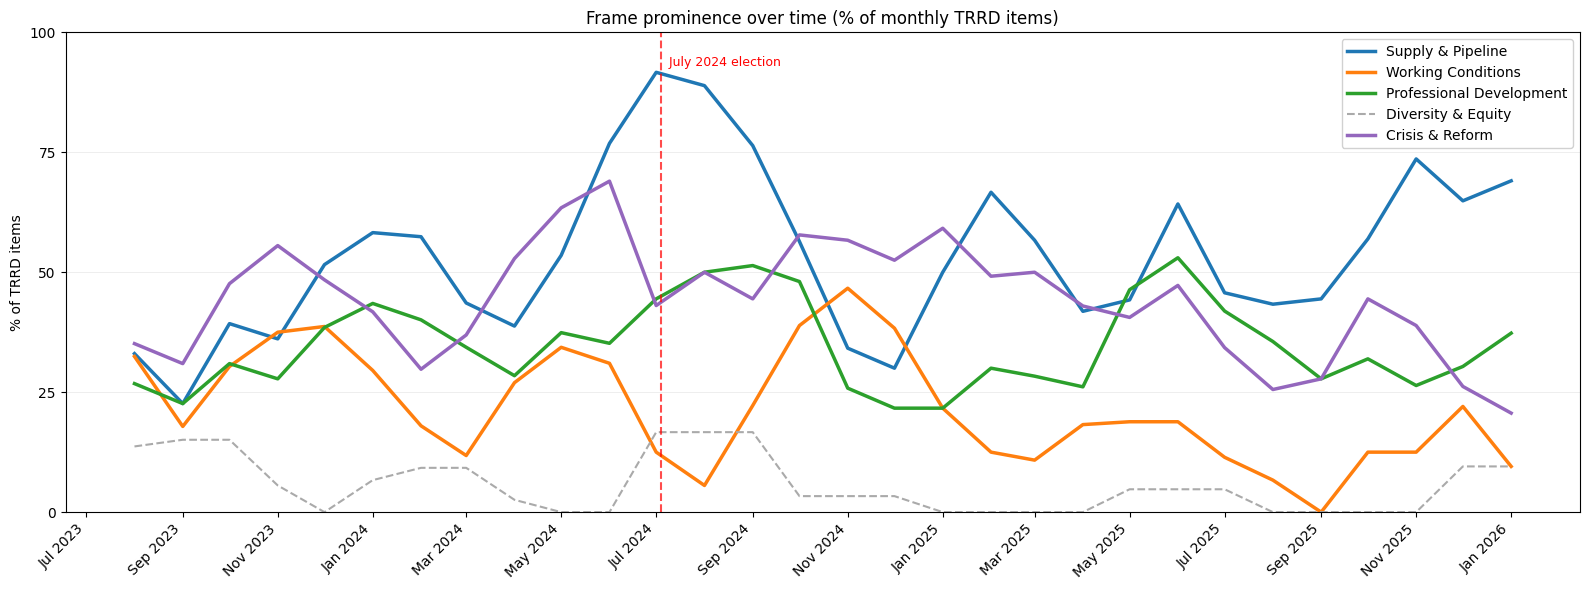

In [35]:
# Frame labels for display
frame_labels = {
    'supply_pipeline': 'Supply & Pipeline',
    'working_conditions': 'Working Conditions',
    'professional_development': 'Professional Development',
    'diversity_equity': 'Diversity & Equity',
    'political_framing': 'Crisis & Reform'
}

# Line styles — mute diversity & equity
line_styles = {
    'supply_pipeline': {'color': '#1f77b4', 'linewidth': 2.5, 'linestyle': '-'},
    'working_conditions': {'color': '#ff7f0e', 'linewidth': 2.5, 'linestyle': '-'},
    'professional_development': {'color': '#2ca02c', 'linewidth': 2.5, 'linestyle': '-'},
    'diversity_equity': {'color': '#aaaaaa', 'linewidth': 1.5, 'linestyle': '--'},
    'political_framing': {'color': '#9467bd', 'linewidth': 2.5, 'linestyle': '-'}
}

# Base counts
rrd_per_month = rrd.groupby(rrd['issue_date'].dt.to_period('M')).size()
rrd_per_month.index = rrd_per_month.index.to_timestamp()
rrd_per_month = rrd_per_month.reindex(full_range, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))

for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    subset = rrd[mask]
    per_month = subset.groupby(subset['issue_date'].dt.to_period('M')).size()
    per_month.index = per_month.index.to_timestamp()
    per_month = per_month.reindex(full_range, fill_value=0)
    pct = (per_month / rrd_per_month * 100).fillna(0)

    style = line_styles[frame]
    smoothed = pct.rolling(3, center=True).mean()
    ax.plot(smoothed.index, smoothed.values,
            label=frame_labels[frame],
            color=style['color'],
            linewidth=style['linewidth'],
            linestyle=style['linestyle'])

# Election marker
ax.axvline(pd.Timestamp('2024-07-04'), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(pd.Timestamp('2024-07-04'), 95,
        '  July 2024 election', color='red', fontsize=9, ha='left', va='top')

ax.set_xticks(full_range[::2])
ax.set_xticklabels([d.strftime('%b %Y') for d in full_range[::2]], rotation=45, ha='right')
ax.set_ylabel('% of TRRD items')
ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.legend(loc='upper right', framealpha=0.9)
ax.set_title('Frame prominence over time (% of monthly TRRD items)')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('bera_outputs/07_frame_prominence_pct.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Frames by Key Organisations

In [36]:
org_totals = rrd_top15['organisation'].value_counts()

frame_org_pct = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd_top15['text'].str.contains(pattern, case=False, na=False)
    counts = rrd_top15[mask]['organisation'].value_counts()
    frame_org_pct[frame] = (counts / org_totals * 100).round(1)

frame_org_pct_df = pd.DataFrame(frame_org_pct).fillna(0)
frame_org_pct_df.to_csv('bera_outputs/table_frame_pct_by_top15_orgs.csv')
frame_org_pct_df

,supply_pipeline,working_conditions,professional_development,diversity_equity,political_framing
organisation,,,,,
5rights_foundation,0.0,0.0,0.0,0.0,0.0
academy_of_social_sciences,0.0,0.0,0.0,0.0,0.0
action_for_children,0.0,0.0,0.0,0.0,0.0
ada_lovelace_institute,0.0,0.0,0.0,0.0,0.0
alan_turing_institute,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
wonkhe,0.0,0.0,0.0,0.0,0.0
working_lives_of_teachers,0.0,0.0,0.0,0.0,0.0
yorkshire_post,0.0,0.0,0.0,0.0,0.0


In [37]:
### *CUT DOWN TO BERA CCT EEF EPI NFER UK GOV (MAYBE PARLIAMENT)
# Filter to key organizations only
orgs_to_keep = ['bera', 'chartered_college_of_teaching', 'eef', 'epi', 'nfer', 'uk_government', 'uk_parliament']
frame_org_pct_df_filtered = frame_org_pct_df[frame_org_pct_df.index.isin(orgs_to_keep)]

# Rename organizations to remove snake_case
org_rename = {
    'bera': 'BERA',
    'chartered_college_of_teaching': 'Chartered College of Teaching',
    'eef': 'Education Endowment Foundation',
    'epi': 'Education Policy Institute',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'uk_parliament': 'UK Parliament'
}

frame_org_pct_df_filtered.index = frame_org_pct_df_filtered.index.map(org_rename)
frame_org_pct_df_filtered.to_csv('bera_outputs/01_table_frame_pct_by_key_orgs.csv')
frame_org_pct_df_filtered

,supply_pipeline,working_conditions,professional_development,diversity_equity,political_framing
organisation,,,,,
BERA,44.4,33.3,11.1,11.1,33.3
Chartered College of Teaching,20.0,0.0,20.0,0.0,20.0
Education Endowment Foundation,100.0,33.3,66.7,0.0,33.3
Education Policy Institute,37.5,25.0,75.0,12.5,37.5
NFER,72.2,16.7,50.0,22.2,50.0
UK Government,44.4,33.3,38.9,0.0,77.8
UK Parliament,100.0,0.0,0.0,0.0,83.3


**How to read this table:** Each cell shows the percentage of that organisation's teacher_rrd items containing at least one keyword from that frame. Rows do not sum to 100% as a single item can contain keywords from multiple frames.

**Frame distribution by organisation:** Supply_pipeline dominates for NFER (72%), UK Parliament (100%), Politics Home (67%) and Schools Week (58%); professional_development is strong for Chartered College (100%), BERA (67%) and EPI (63%); working_conditions is notably high for The Conversation (50%) and UK Government (39%); diversity_equity is marginal across almost all organisations -- highest for Chartered College (60%) and TES (38%) 

In [38]:
#top frame for each organsaiton 
pd.DataFrame(frame_org_pct).fillna(0).idxmax(axis=1)

organisation
5rights_foundation            supply_pipeline
academy_of_social_sciences    supply_pipeline
action_for_children           supply_pipeline
ada_lovelace_institute        supply_pipeline
alan_turing_institute         supply_pipeline
                                   ...       
wonkhe                        supply_pipeline
working_lives_of_teachers     supply_pipeline
yorkshire_post                supply_pipeline
youth_endowment_fund          supply_pipeline
youtube                       supply_pipeline
Length: 212, dtype: object

**Dominant frame by organisation:** Supply_pipeline is the default frame for media, government and research organisations (Schools Week, NFER, UK Parliament, TES, UCL); professional development dominates for academic and practitioner bodies (BERA, EPI, Chartered College); notably UK Government's dominant frame is political_framing rather than supply_pipeline, and The Conversation leads with working_conditions

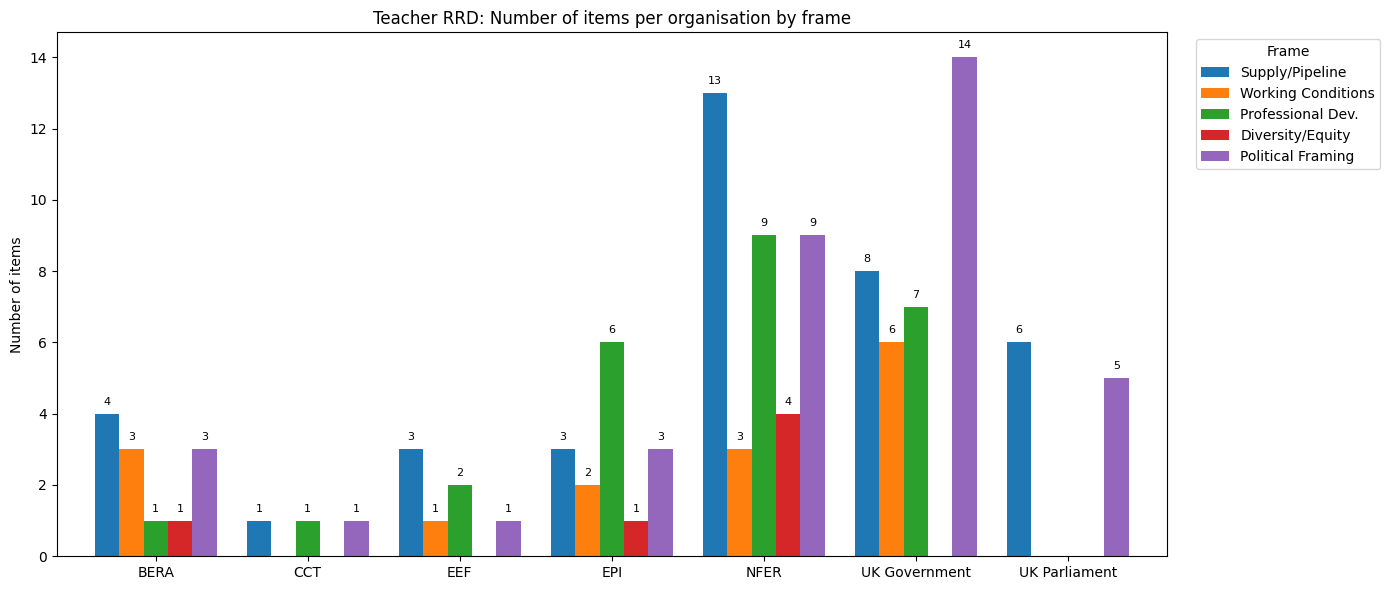

,Supply/Pipeline,Working Conditions,Professional Dev.,Diversity/Equity,Political Framing
organisation,,,,,
BERA,4,3,1,1,3
CCT,1,0,1,0,1
EEF,3,1,2,0,1
EPI,3,2,6,1,3
NFER,13,3,9,4,9
UK Government,8,6,7,0,14
UK Parliament,6,0,0,0,5


In [39]:
# Filter to key organisations
orgs_to_keep = ['bera', 'chartered_college_of_teaching', 'eef', 'epi', 'nfer', 'uk_government', 'uk_parliament']
rrd_key = rrd[rrd['organisation'].isin(orgs_to_keep)]

# Count items per org per frame
frame_org_counts = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd_key['text'].str.contains(pattern, case=False, na=False)
    frame_org_counts[frame] = rrd_key[mask]['organisation'].value_counts()

frame_org_df = pd.DataFrame(frame_org_counts).fillna(0).astype(int)
frame_org_df = frame_org_df.loc[orgs_to_keep]

# Readable names
org_rename = {
    'bera': 'BERA',
    'chartered_college_of_teaching': 'CCT',
    'eef': 'EEF',
    'epi': 'EPI',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'uk_parliament': 'UK Parliament'
}
frame_rename = {
    'supply_pipeline': 'Supply/Pipeline',
    'working_conditions': 'Working Conditions',
    'professional_development': 'Professional Dev.',
    'diversity_equity': 'Diversity/Equity',
    'political_framing': 'Political Framing'
}

frame_org_df.index = frame_org_df.index.map(org_rename)
frame_org_df.columns = frame_org_df.columns.map(frame_rename)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
frame_org_df.plot(kind='bar', ax=ax, width=0.8)

# Add count labels on each bar
for container in ax.containers:
    for bar in container:
        val = int(bar.get_height())
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                    str(val), ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Number of items')
ax.set_xlabel('')
ax.set_title('Teacher RRD: Number of items per organisation by frame')
ax.legend(title='Frame', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.savefig('bera_outputs/11_org_by_frame_counts.png', dpi=150, bbox_inches='tight')
plt.show()

frame_org_df


## Attainment Gap in Teacher RRD

In [40]:
attainment_keywords = ['disadvantaged', 'attainment gap', 'pupil premium', 
                       'deprivation', 'socioeconomic', 'equity', 'social mobility',
                       'poverty', 'closing the gap', 'achievement gap']

pattern = '|'.join(attainment_keywords)
attainment_items = rrd[rrd['text'].str.contains(pattern, case=False, na=False)]

print(f"{len(attainment_items)} of {len(rrd)} teacher_rrd items mention attainment/disadvantage ({len(attainment_items)/len(rrd)*100:.1f}%)")
attainment_items[['issue_date', 'text', 'org_broad_category', 'organisation']].to_csv('bera_outputs/table_attainment_disadvantage_items.csv')
attainment_items[['issue_date', 'text', 'org_broad_category', 'organisation']]

7 of 233 teacher_rrd items mention attainment/disadvantage (3.0%)


,issue_date,text,org_broad_category,organisation
84,2023-09-08,Retaining high-quality teachers in disadvantag...,media_sector,tes
87,2023-09-08,Millions Of GCSE Lessons Taught By Non-Special...,media_sector,politics_home
325,2024-03-01,Report from EEF - Teacher recruitment and rete...,NaN,NaN
621,2024-08-01,WomenEd with BAMEedNetwork and HeadTeachers' R...,NaN,NaN
1543,2026-01-16,BERA - Event: Teacher recruitment and retentio...,academic_sector,bera
1637,2026-02-27,The Chartered College of Teaching - How to ret...,civil_society_nonprofit_sector,chartered_college_of_teaching
1645,2026-03-06,"Department for Education - 6,500 additional te...",government_public_sector,uk_government


**The attainment gap link is almost absent:** Only 7 of 233 teacher_rrd items (3%) explicitly connect recruitment to disadvantage or attainment. 


## Pre/Post Election Frame Shift

In [41]:
pre = rrd[rrd['issue_date'] < '2024-07-04']
post = rrd[rrd['issue_date'] >= '2024-07-04']

print(f"Pre-election: {len(pre)} items | Post-election: {len(post)} items\n")

pre_post_data = []
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    pre_pct = pre['text'].str.contains(pattern, case=False, na=False).sum() / len(pre) * 100
    post_pct = post['text'].str.contains(pattern, case=False, na=False).sum() / len(post) * 100
    diff = post_pct - pre_pct
    pre_post_data.append({'frame': frame, 'pre_pct': round(pre_pct, 1), 'post_pct': round(post_pct, 1), 'change': round(diff, 1)})
    print(f"{frame}: pre {pre_pct:.1f}% → post {post_pct:.1f}% (change: {diff:+.1f}%)")

pd.DataFrame(pre_post_data).to_csv('bera_outputs/table_pre_post_election_frames.csv', index=False)

Pre-election: 106 items | Post-election: 127 items

supply_pipeline: pre 48.1% → post 56.7% (change: +8.6%)
working_conditions: pre 34.0% → post 22.0% (change: -11.9%)
professional_development: pre 34.9% → post 37.0% (change: +2.1%)
diversity_equity: pre 8.5% → post 3.9% (change: -4.6%)
political_framing: pre 50.0% → post 45.7% (change: -4.3%)


**Post-election frame shift:** After July 2024, supply_pipeline strengthens (+8.6%) while working_conditions drops sharply (-10.7%) and political_framing falls (-6.9%). 

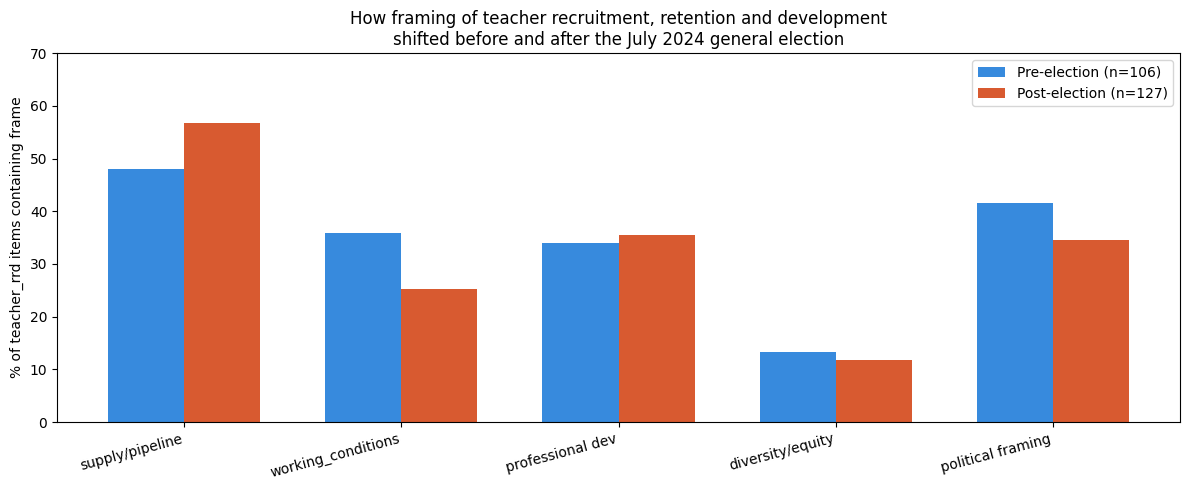

In [42]:
labels = ['supply/pipeline', 'working_conditions', 'professional dev', 'diversity/equity', 'political framing']
pre = [48.1, 35.8, 34.0, 13.2, 41.5]
post = [56.7, 25.2, 35.4, 11.8, 34.6]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, pre, width, label='Pre-election (n=106)', color='#378ADD')
ax.bar(x + width/2, post, width, label='Post-election (n=127)', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('% of teacher_rrd items containing frame')
ax.set_title('How framing of teacher recruitment, retention and development\nshifted before and after the July 2024 general election')
ax.legend()
ax.set_ylim(0, 70)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('bera_outputs/08_pre_post_election_frames.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. EdTech Analysis

In [43]:
edtech = df[df['nl_section'] == 'edtech']
print(f"EdTech: {len(edtech)} items ({len(edtech)/len(df)*100:.1f}% of corpus)")

EdTech: 226 items (13.7% of corpus)


## Top Organisations in EdTech

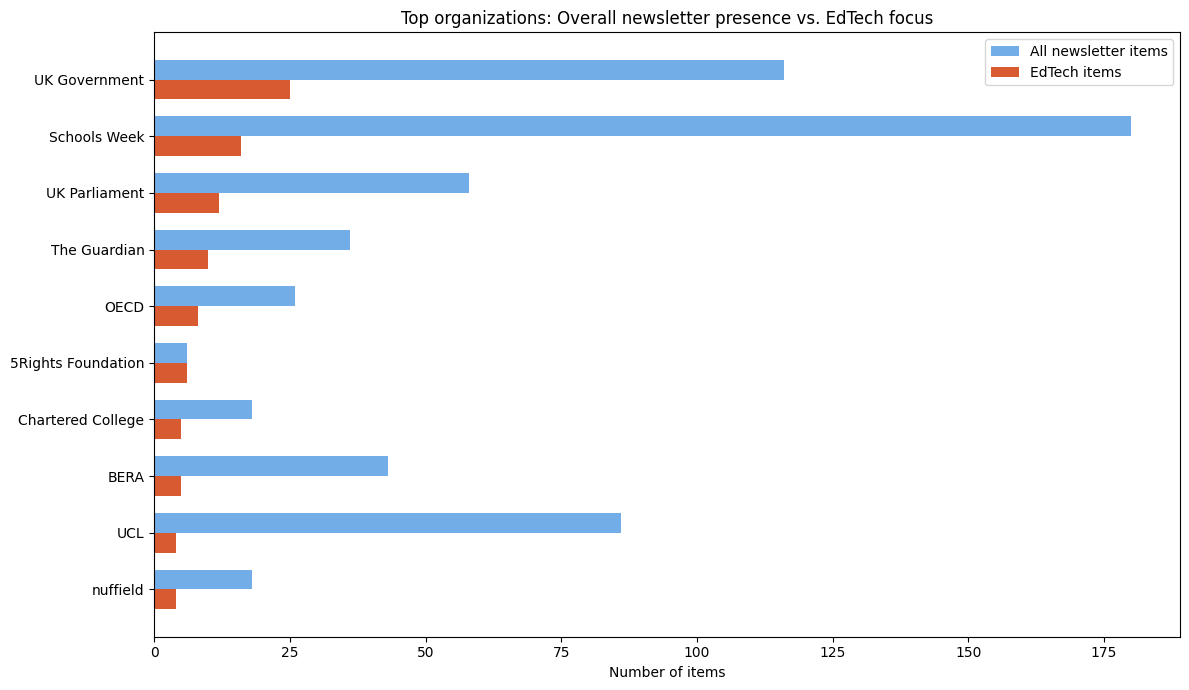


Key patterns:
UK Government: 116 total → 25 edtech (22%)
Schools Week: 180 total → 16 edtech (9%)


In [44]:
edtech = df[df['nl_section'] == 'edtech']

corpus_org = df['organisation'].value_counts()
edtech_org = edtech['organisation'].value_counts()

edtech_ratio_org = pd.DataFrame({
    'corpus_n': corpus_org,
    'edtech_n': edtech_org
}).fillna(0)

edtech_ratio_org['edtech_ratio'] = edtech_ratio_org['edtech_n'] / edtech_ratio_org['corpus_n']

top15_edtech_org = edtech_ratio_org[edtech_ratio_org['edtech_n'] > 0].sort_values('edtech_n', ascending=False).head(10)

# Rename organizations
org_rename = {
    'schools_week': 'Schools Week',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'bera': 'BERA',
    'epi': 'EPI',
    'tes': 'TES',
    'ucl': 'UCL',
    'teacher_tapp': 'Teacher Tapp',
    'uk_parliament': 'UK Parliament',
    'bera_journals': 'BERA Journals',
    'oecd': 'OECD',
    'chartered_college_of_teaching': 'Chartered College',
    'conversation': 'The Conversation',
    'eef': 'EEF',
    'politics_home': 'Politics Home',
    '5rights_foundation': '5Rights Foundation',
    'guardian': 'The Guardian',
    'ofcom': 'Ofcom',
    'childrens_commissioner': "Children's Commissioner",
    'digital_poverty_alliance': 'Digital Poverty Alliance',
    'ada_lovelace_institute': 'Ada Lovelace Institute',
    'nuffield_foundation': 'Nuffield Foundation',
    'lse': 'LSE'
}

top10_edtech = top15_edtech_org.head(10).copy()
top10_edtech.index = top10_edtech.index.map(lambda x: org_rename.get(x, x))

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top10_edtech))
width = 0.35

ax.barh(x - width/2, top10_edtech['corpus_n'], width, label='All newsletter items', color='#378ADD', alpha=0.7)
ax.barh(x + width/2, top10_edtech['edtech_n'], width, label='EdTech items', color='#D85A30')

ax.set_yticks(x)
ax.set_yticklabels(top10_edtech.index)
ax.set_xlabel('Number of items')
ax.set_title('Top organizations: Overall newsletter presence vs. EdTech focus')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('bera_outputs/12_top_orgs_edtech_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top insights
top1 = top10_edtech.index[0]
top2 = top10_edtech.index[1]
print("\nKey patterns:")
print(f"{top1}: {top10_edtech.loc[top1, 'corpus_n']:.0f} total → {top10_edtech.loc[top1, 'edtech_n']:.0f} edtech ({top10_edtech.loc[top1, 'edtech_ratio']:.0%})")
print(f"{top2}: {top10_edtech.loc[top2, 'corpus_n']:.0f} total → {top10_edtech.loc[top2, 'edtech_n']:.0f} edtech ({top10_edtech.loc[top2, 'edtech_ratio']:.0%})")


## EdTech Keywords

In [45]:
edtech_text = ' '.join(edtech['text'].dropna().tolist()).lower()
edtech_words = re.findall(r'\b[a-z]{3,}\b', edtech_text)
edtech_counts = Counter(w for w in edtech_words if w not in stopwords)
edtech_counts.most_common(10)

[('education', 187),
 ('digital', 103),
 ('schools', 95),
 ('children', 85),
 ('research', 59),
 ('use', 51),
 ('can', 49),
 ('report', 47),
 ('here', 46),
 ('government', 37)]

## EdTech Frame Analysis

In [46]:
edtech_frames = {
    'ai_tools': ['artificial', 'intelligence', 'generative', 'chatgpt', 'genai', 
                 'tools', 'technology', 'technologies', 'tech', 'digital', 'platforms',
                 'personalised', 'marking', 'automation'],
    
    'phones_safety': ['phones', 'phone', 'smartphones', 'smartphone', 'mobile', 
                      'ban', 'bans', 'online', 'internet', 'screen', 'offline',
                      'safety', 'risks', 'vulnerabilities', 'protection'],
    
    'equity_access': ['disadvantaged', 'divide', 'poverty', 'equity', 'inclusion',
                      'inclusive', 'access', 'send', 'special', 'ehcps', 'families',
                      'communities', 'race', 'whiteness'],
    
    'governance_regulation': ['regulation', 'governance', 'ethics', 'ethical', 
                               'rights', 'statutory', 'guidance', 'consultation',
                               'inquiry', 'committee', 'parliament', 'bill',
                               'standards', 'responsibility'],
    
    'learning_outcomes': ['learning', 'assessment', 'curriculum', 'outcomes',
                          'evidence', 'impact', 'evaluation', 'literacy',
                          'skills', 'feedback', 'classroom', 'teaching'],
    
    'teacher_development': ['teacher', 'teachers', 'cpd', 'professional', 
                             'workforce', 'training', 'development', 'leadership',
                             'educators', 'wellbeing', 'workload', 'lesson']
}

### EdTech Frames by Organisation

In [47]:
edtech_org_totals = edtech_top15['organisation'].value_counts()
edtech_frame_org_pct = {}
for frame, keywords in edtech_frames.items():
    pattern = '|'.join(keywords)
    mask = edtech_top15['text'].str.contains(pattern, case=False, na=False)
    counts = edtech_top15[mask]['organisation'].value_counts()
    edtech_frame_org_pct[frame] = (counts / edtech_org_totals * 100).round(1)

edtech_frame_org_pct_df = pd.DataFrame(edtech_frame_org_pct).fillna(0)
edtech_frame_org_pct_df.to_csv('bera_outputs/table_edtech_frame_pct_by_top15_orgs.csv')
edtech_frame_org_pct_df

,ai_tools,phones_safety,equity_access,governance_regulation,learning_outcomes,teacher_development
organisation,,,,,,
5rights_foundation,66.7,83.3,16.7,100.0,0.0,0.0
academy_of_social_sciences,0.0,0.0,0.0,0.0,0.0,0.0
action_for_children,0.0,0.0,0.0,0.0,0.0,0.0
ada_lovelace_institute,0.0,0.0,0.0,0.0,0.0,0.0
alan_turing_institute,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
wonkhe,0.0,0.0,0.0,0.0,0.0,0.0
working_lives_of_teachers,0.0,0.0,0.0,0.0,0.0,0.0
yorkshire_post,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
pd.DataFrame(edtech_frame_org_pct).fillna(0).idxmax(axis=1)

organisation
5rights_foundation            governance_regulation
academy_of_social_sciences                 ai_tools
action_for_children                        ai_tools
ada_lovelace_institute                     ai_tools
alan_turing_institute                      ai_tools
                                      ...          
wonkhe                                     ai_tools
working_lives_of_teachers                  ai_tools
yorkshire_post                             ai_tools
youth_endowment_fund                       ai_tools
youtube                                    ai_tools
Length: 212, dtype: object

**Dominant edtech frame by organisation:** AI_tools dominates for 11 of 15 organisations -- spanning media (Schools Week), government (DfE), academic (UCL, LSE, BERA), think tanks (Nuffield, Ada Lovelace) and practitioner bodies (Chartered College) 

## EdTech-Teacher Overlap

In [49]:
edtech = df[df['nl_section'] == 'edtech']

teacher_adjacent = edtech[edtech['text'].str.contains(
    'teacher|cpd|professional development|staff|workforce', 
    case=False, na=False)]

print(f"{len(teacher_adjacent)} of {len(edtech)} edtech items contain teacher-adjacent terms ({len(teacher_adjacent)/len(edtech)*100:.1f}%)")
teacher_adjacent[['issue_date', 'text', 'org_broad_category', 'organisation']].to_csv('bera_outputs/table_edtech_teacher_adjacent.csv')
teacher_adjacent[['issue_date', 'text', 'org_broad_category', 'organisation']].head(20)

38 of 226 edtech items contain teacher-adjacent terms (16.8%)


,issue_date,text,org_broad_category,organisation
23,2023-07-16,Tony Blair Institute - The Future of Learning:...,knowledge_mobiliser_think_tank_sector,tony_blair_institute
89,2023-09-08,Artificial intelligence (AI) is still unsuitab...,media_sector,tes
113,2023-10-19,AI in schools now Oriel Square report on Gener...,commercial_private_sector,oriel_square
174,2023-11-03,New support for teachers powered by Artificial...,government_public_sector,uk_government
213,2023-12-01,The inexorable rise of AI Teacher Tapp Blog Re...,knowledge_mobiliser_think_tank_sector,teacher_tapp
259,2024-01-19,Artificial Incentives: Will students feel moti...,media_sector,rebecca_allen
266,2024-01-26,Five changes experts suggest on AI in schools ...,media_sector,schools_week
276,2024-02-05,Tech4Teachers White paper The digital poverty ...,civil_society_nonprofit_sector,digital_poverty_alliance
434,2024-04-26,DfE Roundtable - Deputy Prime Minister and Edu...,government_public_sector,uk_government
523,2024-05-24,Schools Week - Ministers plan to appoint edtec...,media_sector,schools_week


**EdTech adjacency:** 38 of 226 edtech items (16.8%) contain teacher-adjacent terms, spread across media, government, academic and think tank sources. The content splits into two distinct theories of teacher development: AI as a productivity tool for teachers (lesson preparation, workload reduction -- fE, Teacher Tapp, Schools Week) and AI as a professional development resource (CPD, digital capital -- NFER, BERA). 

### Cross-section Organisation Overlap

In [50]:
# Orgs appearing in both TRRD and EdTech
trrd_orgs = set(rrd['organisation'].unique())
edtech_orgs = set(edtech['organisation'].unique())

overlap_orgs = trrd_orgs.intersection(edtech_orgs)
print(f"Organisations appearing in both TRRD and EdTech: {len(overlap_orgs)}")

# How many items each overlap org contributes to each section
overlap_df = pd.DataFrame({
    'trrd_n': rrd[rrd['organisation'].isin(overlap_orgs)]['organisation'].value_counts(),
    'edtech_n': edtech[edtech['organisation'].isin(overlap_orgs)]['organisation'].value_counts()
}).fillna(0).astype(int)

overlap_df['total'] = overlap_df['trrd_n'] + overlap_df['edtech_n']
print(overlap_df.sort_values('total', ascending=False).head(15))

Organisations appearing in both TRRD and EdTech: 20
                               trrd_n  edtech_n  total
organisation                                          
schools_week                       64        16     80
uk_government                      18        25     43
nfer                               18         2     20
uk_parliament                       6        12     18
bera                                9         5     14
guardian                            3        10     13
oecd                                5         8     13
ucl                                 7         4     11
chartered_college_of_teaching       5         5     10
epi                                 8         2     10
teacher_tapp                        6         3      9
tes                                 8         1      9
conversation                        4         4      8
bera_journals                       5         2      7
eef                                 3         3      6


In [51]:
edtech_teacher = edtech[edtech['text'].str.contains(
    '|'.join(edtech_frames['teacher_development']), case=False, na=False)]

print(f"EdTech items with teacher development framing: {len(edtech_teacher)}")
print(f"\nTop organisations:")
print(edtech_teacher['organisation'].value_counts().head(15))

EdTech items with teacher development framing: 67

Top organisations:
organisation
uk_government                           7
uk_parliament                           7
schools_week                            5
chartered_college_of_teaching           3
nuffield                                3
teacher_tapp                            3
nfer                                    2
bera                                    2
conversation                            2
eef                                     1
edtech_innovation_hub                   1
harvard_graduate_school_of_education    1
nesta                                   1
internet_matters                        1
guardian                                1
Name: count, dtype: int64


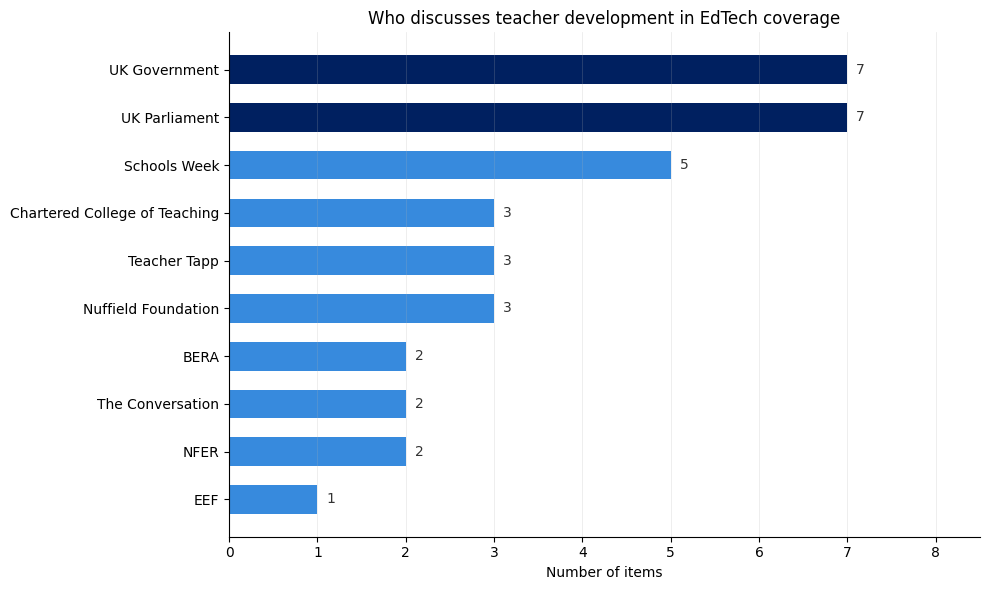

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

org_rename = {
    'uk_government': 'UK Government',
    'uk_parliament': 'UK Parliament',
    'schools_week': 'Schools Week',
    'chartered_college_of_teaching': 'Chartered College of Teaching',
    'nuffield': 'Nuffield Foundation',
    'teacher_tapp': 'Teacher Tapp',
    'nfer': 'NFER',
    'bera': 'BERA',
    'conversation': 'The Conversation',
    'eef': 'EEF'
}

counts = edtech_teacher['organisation'].value_counts().head(10)
counts.index = counts.index.map(lambda x: org_rename.get(x, x))
counts = counts.sort_values()

colors = ['#002060' if org in ['UK Government', 'UK Parliament'] 
          else '#378ADD' for org in counts.index]

bars = ax.barh(counts.index, counts.values, color=colors, height=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=10, color='#333333')

ax.set_xlabel('Number of items')
ax.set_title('Who discusses teacher development in EdTech coverage')
ax.set_xlim(0, counts.max() + 1.5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(axis='x', alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('bera_outputs/edtech_teacher_orgs.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Frame breakdown for the 67 edtech teacher items
edtech_teacher_frames = {}
for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    count = edtech_teacher['text'].str.contains(pat, case=False, na=False).sum()
    edtech_teacher_frames[frame] = round(count / len(edtech_teacher) * 100, 1)

frame_rename = {
    'ai_tools': 'AI & Digital Tools',
    'phones_safety': 'Phones & Safety',
    'equity_access': 'Equity & Access',
    'governance_regulation': 'Governance & Regulation',
    'learning_outcomes': 'Learning Outcomes',
    'teacher_development': 'Teacher Development'
}

labels = [frame_rename[k] for k in edtech_teacher_frames]
values = list(edtech_teacher_frames.values())

In [61]:
# Frame breakdown for the 67 edtech teacher items
edtech_teacher_frames = {}
for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    count = edtech_teacher['text'].str.contains(pat, case=False, na=False).sum()
    edtech_teacher_frames[frame] = round(count / len(edtech_teacher) * 100, 1)

frame_rename = {
    'ai_tools': 'AI & Digital Tools',
    'phones_safety': 'Phones & Safety',
    'equity_access': 'Equity & Access',
    'governance_regulation': 'Governance & Regulation',
    'learning_outcomes': 'Learning Outcomes',
    'teacher_development': 'Teacher Development'
}

labels = [frame_rename[k] for k in edtech_teacher_frames]
values = list(edtech_teacher_frames.values())

In [66]:
for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    count = edtech['text'].str.contains(pat, case=False, na=False).sum()
    print(f"{frame}: {count} ({round(count/len(edtech)*100,1)}%)")

ai_tools: 136 (60.2%)
phones_safety: 78 (34.5%)
equity_access: 42 (18.6%)
governance_regulation: 61 (27.0%)
learning_outcomes: 92 (40.7%)
teacher_development: 67 (29.6%)


In [67]:
for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    count = edtech_teacher['text'].str.contains(pat, case=False, na=False).sum()
    print(f"{frame}: {count} ({round(count/len(edtech_teacher)*100,1)}%)")

ai_tools: 44 (65.7%)
phones_safety: 21 (31.3%)
equity_access: 11 (16.4%)
governance_regulation: 18 (26.9%)
learning_outcomes: 39 (58.2%)
teacher_development: 67 (100.0%)


In [69]:
edtech = df[df['nl_section'] == 'edtech'].copy()

for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    edtech[frame] = edtech['text'].str.contains(pat, case=False, na=False).astype(int)

edtech['is_teacher'] = edtech['text'].str.contains(
    '|'.join(edtech_frames['teacher_development']), case=False, na=False).astype(int)

frames_to_compare = ['ai_tools', 'phones_safety', 'equity_access', 
                     'governance_regulation', 'learning_outcomes', 'teacher_development']

results = []
for frame in frames_to_compare:
    teacher_pct = edtech[edtech['is_teacher']==1][frame].mean() * 100
    non_teacher_pct = edtech[edtech['is_teacher']==0][frame].mean() * 100
    results.append({
        'Frame': frame,
        'Teacher items (%)': round(teacher_pct, 1),
        'Non-teacher items (%)': round(non_teacher_pct, 1),
        'Difference': round(teacher_pct - non_teacher_pct, 1)
    })

ct = pd.DataFrame(results).sort_values('Difference', ascending=False)
print(ct.to_string(index=False))

                Frame  Teacher items (%)  Non-teacher items (%)  Difference
  teacher_development              100.0                    0.0       100.0
    learning_outcomes               58.2                   33.3        24.9
             ai_tools               65.7                   57.9         7.8
governance_regulation               26.9                   27.0        -0.2
        equity_access               16.4                   19.5        -3.1
        phones_safety               31.3                   35.8        -4.5


In [73]:
edtech = df[df['nl_section'] == 'edtech'].copy()

for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    edtech[frame] = edtech['text'].str.contains(pat, case=False, na=False).astype(int)

edtech['is_teacher'] = edtech['text'].str.contains(
    '|'.join(edtech_frames['teacher_development']), case=False, na=False).astype(int)

frames_to_compare = ['ai_tools', 'phones_safety', 'equity_access', 
                     'governance_regulation', 'learning_outcomes', 'teacher_development']

results = []
for frame in frames_to_compare:
    teacher_pct = edtech[edtech['is_teacher']==1][frame].mean() * 100
    non_teacher_pct = edtech[edtech['is_teacher']==0][frame].mean() * 100
    results.append({
        'Frame': frame,
        'Teacher items (%)': round(teacher_pct, 1),
        'Non-teacher items (%)': round(non_teacher_pct, 1),
        'Difference': round(teacher_pct - non_teacher_pct, 1)
    })

ct = pd.DataFrame(results).sort_values('Difference', ascending=False)
print(ct.to_string(index=False))

                Frame  Teacher items (%)  Non-teacher items (%)  Difference
  teacher_development              100.0                    0.0       100.0
    learning_outcomes               58.2                   33.3        24.9
             ai_tools               65.7                   57.9         7.8
governance_regulation               26.9                   27.0        -0.2
        equity_access               16.4                   19.5        -3.1
        phones_safety               31.3                   35.8        -4.5


In [75]:
edtech_copy = df[df['nl_section'] == 'edtech'].copy()

frame_labels = {
    'ai_tools': 'AI & Tools',
    'phones_safety': 'Phones & Safety', 
    'equity_access': 'Equity & Access',
    'governance_regulation': 'Governance',
    'learning_outcomes': 'Learning Outcomes',
    'teacher_development': 'Teacher Development'
}

# Add frame columns
for frame, keywords in edtech_frames.items():
    pat = '|'.join(keywords)
    edtech_copy[frame] = edtech_copy['text'].str.contains(pat, case=False, na=False).astype(int)

# Co-occurrence matrix
frames_list = list(edtech_frames.keys())
cooc = pd.DataFrame(index=frames_list, columns=frames_list, dtype=float)

for f1 in frames_list:
    for f2 in frames_list:
        f1_items = edtech_copy[edtech_copy[f1] == 1]
        cooc.loc[f1, f2] = round(f1_items[f2].mean() * 100, 1)

cooc.index = [frame_labels[f] for f in frames_list]
cooc.columns = [frame_labels[f] for f in frames_list]
print(cooc.to_string())

                     AI & Tools  Phones & Safety  Equity & Access  Governance  Learning Outcomes  Teacher Development
AI & Tools                100.0             25.0             25.0        29.4               44.9                 32.4
Phones & Safety            43.6            100.0             16.7        35.9               38.5                 26.9
Equity & Access            81.0             31.0            100.0        26.2               42.9                 26.2
Governance                 65.6             45.9             18.0       100.0               37.7                 29.5
Learning Outcomes          66.3             32.6             19.6        25.0              100.0                 42.4
Teacher Development        65.7             31.3             16.4        26.9               58.2                100.0


# 5. Mental Health & Wellbeing

## Build Mental Health Subset

In [70]:
#BULD THE DATASET
mh_keywords = ['wellbeing', 'well-being', 'mental health', 'workload', 
                'stress', 'resilience', 'anxiety', 'emotional', 'burnout',
                'mindfulness', 'pastoral', 'safeguarding']

mh_sections = df[df['nl_section'].isin(['teacher_rrd', 'what_matters_ed'])]

pattern = '|'.join(mh_keywords)
mh = mh_sections[mh_sections['text'].str.contains(pattern, case=False, na=False)].copy()

print(f"Mental health & wellbeing corpus: {len(mh)} items")
print(f"From teacher_rrd: {len(mh[mh['nl_section'] == 'teacher_rrd'])}")
print(f"From what_matters_ed: {len(mh[mh['nl_section'] == 'what_matters_ed'])}")


Mental health & wellbeing corpus: 53 items
From teacher_rrd: 26
From what_matters_ed: 27


In [71]:
mh_per_month = mh.groupby(mh['issue_date'].dt.to_period('M')).size()
mh_per_month.index = mh_per_month.index.to_timestamp()
mh_per_month = mh_per_month.reindex(full_range, fill_value=0)


In [72]:
print(f"Total mh items: {len(mh)}")
print(f"From teacher_rrd: {len(mh[mh['nl_section'] == 'teacher_rrd'])}")
print(f"From what_matters_ed: {len(mh[mh['nl_section'] == 'what_matters_ed'])}")
print(f"\nItems per year:")
print(mh['issue_date'].dt.year.value_counts().sort_index())
print(f"\nMonthly counts (non-zero only):")
print(mh_per_month[mh_per_month > 0])

Total mh items: 53
From teacher_rrd: 26
From what_matters_ed: 27

Items per year:
issue_date
2023    11
2024    21
2025    19
2026     2
Name: count, dtype: int64

Monthly counts (non-zero only):
2023-07-01    3
2023-09-01    3
2023-10-01    3
2023-11-01    2
2024-01-01    1
2024-02-01    1
2024-03-01    2
2024-04-01    2
2024-05-01    7
2024-06-01    2
2024-10-01    4
2024-11-01    1
2024-12-01    1
2025-01-01    1
2025-02-01    1
2025-03-01    2
2025-04-01    1
2025-05-01    7
2025-06-01    1
2025-07-01    1
2025-10-01    1
2025-11-01    2
2025-12-01    2
2026-01-01    1
dtype: int64


## Mental Health Frame Analysis

Workload & burnout: 13 (24.5%)
Pupil wellbeing: 27 (50.9%)
Teacher wellbeing: 30 (56.6%)
Resilience & mindfulness: 5 (9.4%)
Policy & reform: 13 (24.5%)


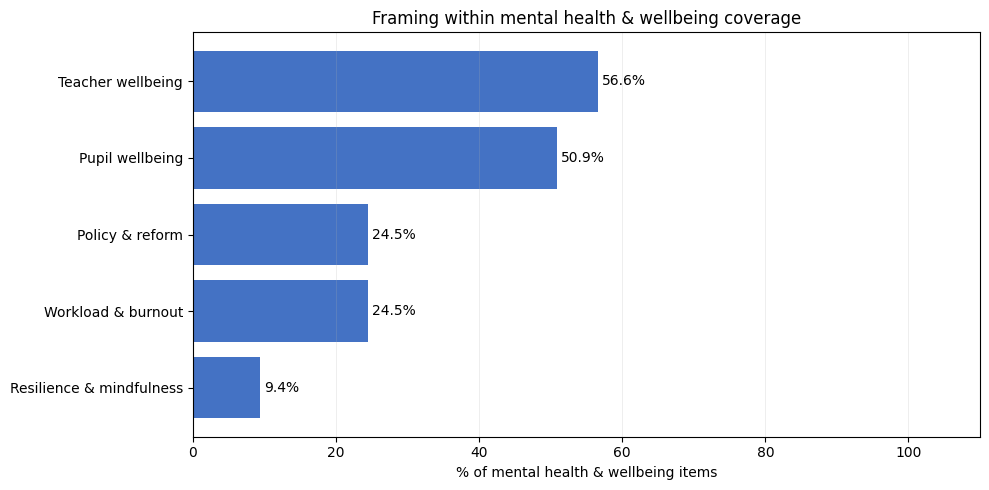

In [58]:
# FRAMEW ANALYSIS 
mh_frames = {
    'Workload & burnout': ['workload', 'burnout', 'stress', 'overwork', 'pressures'],
    'Pupil wellbeing': ['pupil', 'student', 'children', 'child', 'young people', 'pastoral', 'safeguarding'],
    'Teacher wellbeing': ['teacher', 'staff', 'workforce', 'professional'],
    'Resilience & mindfulness': ['resilience', 'mindfulness', 'emotional', 'anxiety', 'coping'],
    'Policy & reform': ['policy', 'government', 'dfe', 'reform', 'guidance', 'ofsted']
}

mh_frame_counts = []
for frame, keywords in mh_frames.items():
    pat = '|'.join(keywords)
    count = mh['text'].str.contains(pat, case=False, na=False).sum()
    mh_frame_counts.append({
        'frame': frame,
        'n': count,
        'pct': round(count / len(mh) * 100, 1)
    })
    print(f"{frame}: {count} ({count/len(mh)*100:.1f}%)")

mh_frame_df = pd.DataFrame(mh_frame_counts).sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mh_frame_df['frame'], mh_frame_df['pct'], color='#4472C4')
for bar, val in zip(bars, mh_frame_df['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlabel('% of mental health & wellbeing items')
ax.set_title('Framing within mental health & wellbeing coverage')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig('bera_outputs/mh_frames.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Mental Health: Pre/Post Election

In [59]:
pre = mh[mh['issue_date'] < '2024-07-04']
post = mh[mh['issue_date'] >= '2024-07-04']

mh_prepost = []
for frame, keywords in mh_frames.items():
    pat = '|'.join(keywords)
    pre_pct = round(pre['text'].str.contains(pat, case=False, na=False).sum() / len(pre) * 100, 1)
    post_pct = round(post['text'].str.contains(pat, case=False, na=False).sum() / len(post) * 100, 1)
    change = round(post_pct - pre_pct, 1)
    mh_prepost.append({'Frame': frame, 'Pre-election (%)': pre_pct, 'Post-election (%)': post_pct, 'Change (%)': change})

mh_prepost_df = pd.DataFrame(mh_prepost).sort_values('Change (%)', ascending=False)
print(mh_prepost_df.to_string(index=False))
mh_prepost_df.to_csv('bera_outputs/table_mh_prepost.csv', index=False)

                   Frame  Pre-election (%)  Post-election (%)  Change (%)
         Pupil wellbeing              42.3               59.3        17.0
Resilience & mindfulness               7.7               11.1         3.4
         Policy & reform              30.8               18.5       -12.3
       Teacher wellbeing              65.4               48.1       -17.3
      Workload & burnout              34.6               14.8       -19.8


## Top Organisations: Mental Health

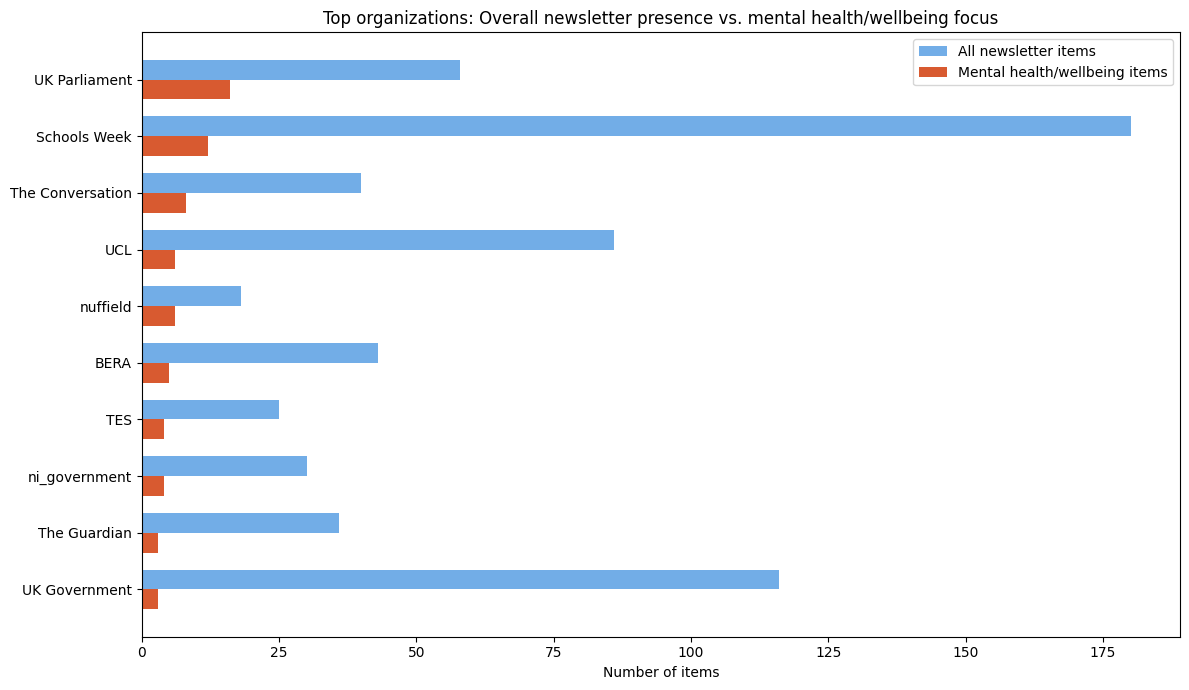


Key patterns:
UK Parliament: 58 total → 16 mental health (28%)
Schools Week: 180 total → 12 mental health (7%)


In [60]:
# Mental health items
mh_keywords = ['mental health', 'wellbeing', 'well-being', 'burnout', 'stress', 'anxiety', 
               'depression', 'resilience', 'welfare', 'pastoral', 'counselling', 'counseling',
               'mindfulness', 'self-care', 'emotional', 'loneliness', 'suicide', 'safeguarding',
               'workload', 'work-life', 'work life balance']

mh_pattern = '|'.join(mh_keywords)
mh = df[df['text'].str.contains(mh_pattern, case=False, na=False)]

# Build comparison table
corpus_org = df['organisation'].value_counts()
mh_org = mh['organisation'].value_counts()

mh_ratio_org = pd.DataFrame({
    'corpus_n': corpus_org,
    'mh_n': mh_org
}).fillna(0)

mh_ratio_org['mh_ratio'] = mh_ratio_org['mh_n'] / mh_ratio_org['corpus_n']

top10_mh = mh_ratio_org[mh_ratio_org['mh_n'] > 0].sort_values('mh_n', ascending=False).head(10).copy()

# Rename organizations
org_rename = {
    'schools_week': 'Schools Week',
    'nfer': 'NFER',
    'uk_government': 'UK Government',
    'bera': 'BERA',
    'epi': 'EPI',
    'tes': 'TES',
    'ucl': 'UCL',
    'teacher_tapp': 'Teacher Tapp',
    'uk_parliament': 'UK Parliament',
    'bera_journals': 'BERA Journals',
    'oecd': 'OECD',
    'chartered_college_of_teaching': 'Chartered College',
    'conversation': 'The Conversation',
    'eef': 'EEF',
    'politics_home': 'Politics Home',
    'ofsted': 'Ofsted',
    'guardian': 'The Guardian',
    'nuffield_foundation': 'Nuffield Foundation',
    'education_endowment_foundation': 'EEF',
    'education_policy_institute': 'EPI'
}

top10_mh.index = top10_mh.index.map(lambda x: org_rename.get(x, x))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top10_mh))
width = 0.35

ax.barh(x - width/2, top10_mh['corpus_n'], width, label='All newsletter items', color='#378ADD', alpha=0.7)
ax.barh(x + width/2, top10_mh['mh_n'], width, label='Mental health/wellbeing items', color='#D85A30')

ax.set_yticks(x)
ax.set_yticklabels(top10_mh.index)
ax.set_xlabel('Number of items')
ax.set_title('Top organizations: Overall newsletter presence vs. mental health/wellbeing focus')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('bera_outputs/13_top_orgs_mental_health.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insights
top1 = top10_mh.index[0]
top2 = top10_mh.index[1]
print("\nKey patterns:")
print(f"{top1}: {top10_mh.loc[top1, 'corpus_n']:.0f} total → {top10_mh.loc[top1, 'mh_n']:.0f} mental health ({top10_mh.loc[top1, 'mh_ratio']:.0%})")
print(f"{top2}: {top10_mh.loc[top2, 'corpus_n']:.0f} total → {top10_mh.loc[top2, 'mh_n']:.0f} mental health ({top10_mh.loc[top2, 'mh_ratio']:.0%})")


In [76]:
mh_teacher = mh[mh['text'].str.contains(
    'teacher|teachers|staff|workforce', case=False, na=False)]
print(f"{len(mh_teacher)} items mention teachers specifically")
print(mh_teacher['organisation'].value_counts().head(5))

28 items mention teachers specifically
organisation
schools_week                 7
bera                         2
teacher_tapp                 2
education_support_charity    2
uk_government                2
Name: count, dtype: int64
